<a href="https://colab.research.google.com/github/sheeraannisa-web/ml-model-life-expectancy/blob/main/UTS_Machine_Learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Prediksi Angka Harapan Hidup Berdasarkan Faktor Kesehatan dan Ekonomi (Decision Tree, Random Forest, XGBoost)

### DATA UNDERSTANDING






TAHAPAN 1: DATA UNDERSTANDING
Total Observasi : 9928 baris
Total Variabel   : 22 kolom
Data Duplikat    : 0

AUDIT VARIABEL & QUALITY CHECK


,Tipe Data,Missing Values,% Missing,Unique Values
Country,object,0,0.0,256
Year,int64,0,0.0,20
Gender,object,0,0.0,2
Life expectancy,float64,0,0.0,7477
Unemployment,float64,0,0.0,7829
Infant Mortality,float64,0,0.0,2471
GDP,float64,0,0.0,4810
GNI,float64,0,0.0,4717
Clean fuels and cooking technologies,float64,0,0.0,1688
Per Capita,float64,0,0.0,4810



STATISTIK DESKRIPTIF (NUMERIK)


,count,mean,std,min,25%,50%,75%,max,median,skewness
Year,9928.0,2.009495e+03,5.761572e+00,2.000000e+03,2.005000e+03,2.009000e+03,2.014000e+03,2.019000e+03,2.009000e+03,-0.000795
Life expectancy,9928.0,6.983364e+01,9.301549e+00,3.886100e+01,6.389425e+01,7.144500e+01,7.684525e+01,8.810000e+01,7.144500e+01,-0.617472
Unemployment,9928.0,8.256285e+00,6.155461e+00,5.200000e-02,4.331000e+00,6.561500e+00,1.013275e+01,4.316600e+01,6.561500e+00,1.768284
Infant Mortality,9928.0,3.023477e+01,2.546081e+01,1.400000e+00,9.300000e+00,2.330000e+01,4.486505e+01,1.462000e+02,2.330000e+01,1.088911
GDP,9928.0,2.032870e+12,7.249370e+12,6.310127e+07,7.267552e+09,4.524797e+10,5.012787e+11,8.756805e+13,4.524797e+10,5.889286
GNI,9928.0,2.042054e+12,7.254721e+12,7.280219e+07,7.584112e+09,4.594036e+10,5.230617e+11,8.753272e+13,4.594036e+10,5.909525
Clean fuels and cooking technologies,9928.0,6.059302e+01,3.696399e+01,0.000000e+00,2.300000e+01,6.195000e+01,9.933359e+01,1.000000e+02,6.195000e+01,-0.383356
Per Capita,9928.0,1.266885e+04,1.944760e+04,1.119272e+02,1.366059e+03,4.348605e+03,1.444394e+04,1.803667e+05,4.348605e+03,2.994002
Mortality caused by road traffic injury,9928.0,1.822921e+01,8.222567e+00,0.000000e+00,1.270000e+01,1.822921e+01,2.410000e+01,6.460000e+01,1.822921e+01,0.212769
Tuberculosis Incidence,9928.0,1.360432e+02,1.760900e+02,0.000000e+00,2.100000e+01,8.200000e+01,1.590000e+02,1.590000e+03,8.200000e+01,3.097059



RINGKASAN DATA KATEGORIKAL


,count,unique,top,freq
Country,9928,256,Afghanistan,40
Gender,9928,2,Female,4964


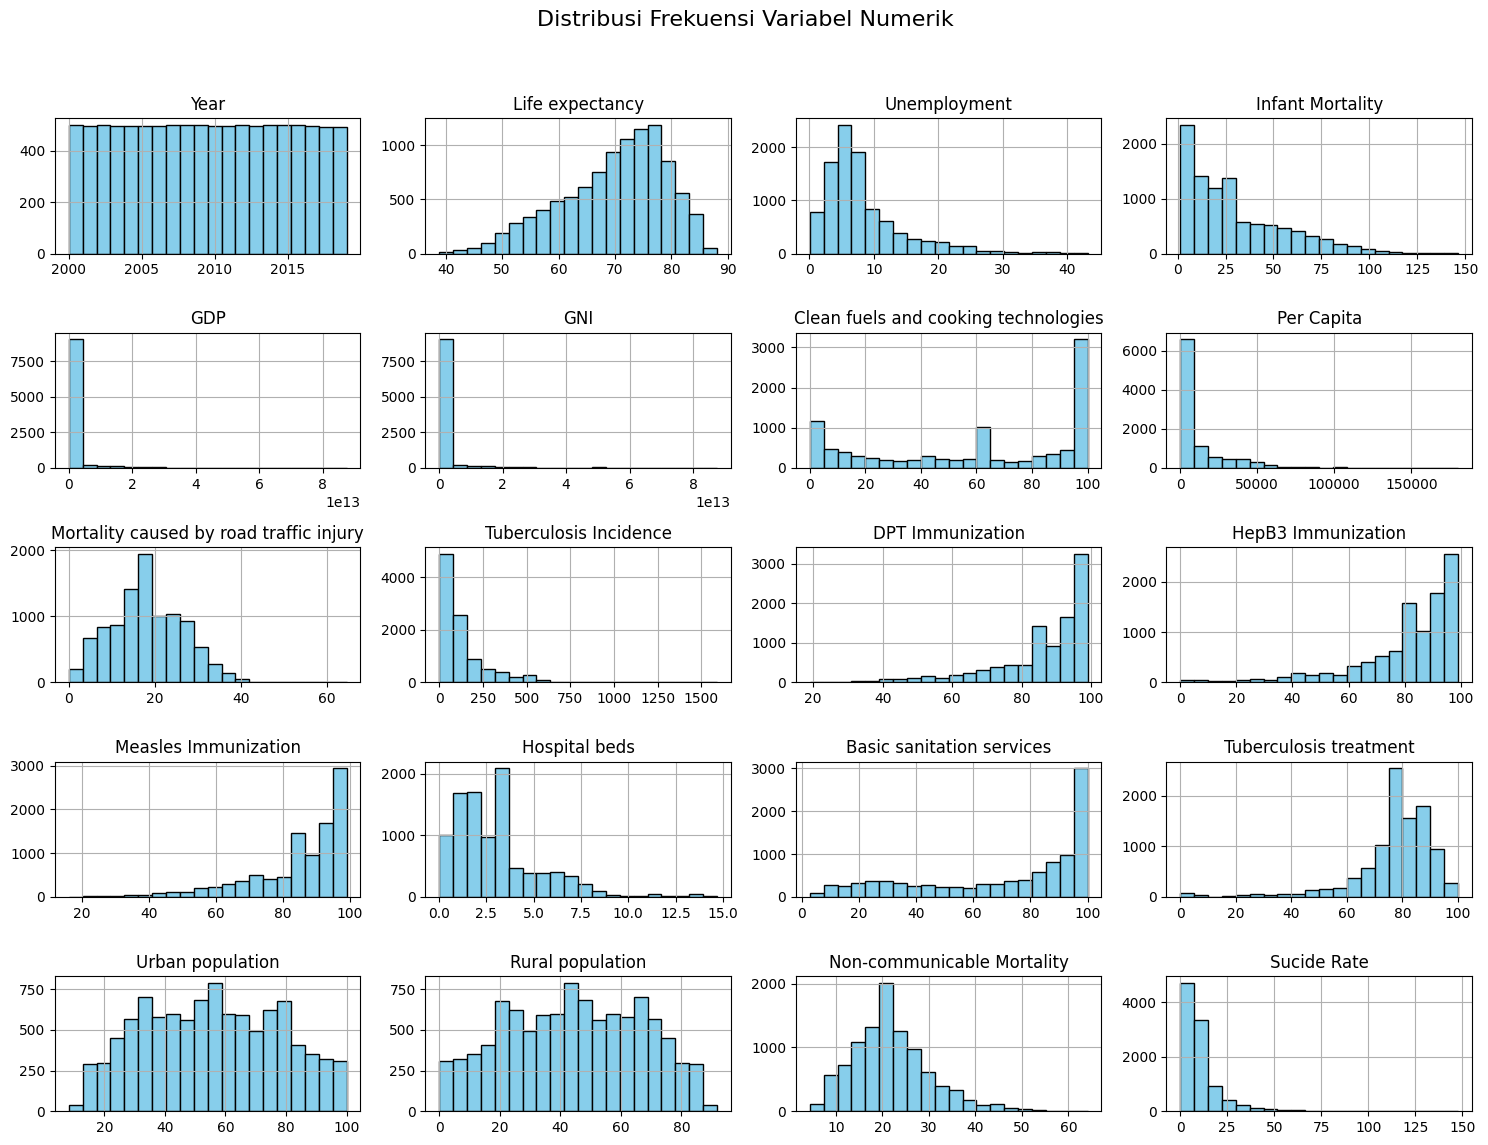

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# 1. Load Dataset
df = pd.read_csv('final_data.csv')

print("="*50)
print("TAHAPAN 1: DATA UNDERSTANDING")
print("="*50)

# 2. Informasi Dimensi dan Integritas
print(f"Total Observasi : {df.shape[0]} baris")
print(f"Total Variabel   : {df.shape[1]} kolom")
print(f"Data Duplikat    : {df.duplicated().sum()}")

# 3. Klasifikasi Variabel & Audit Kualitas
print("\n" + "="*50)
print("AUDIT VARIABEL & QUALITY CHECK")
print("="*50)

# Menghitung statistik kualitas tambahan
quality_audit = pd.DataFrame({
    'Tipe Data': df.dtypes,
    'Missing Values': df.isnull().sum(),
    '% Missing': round((df.isnull().sum() / len(df)) * 100, 2),
    'Unique Values': df.nunique()
})
display(quality_audit)

# 4. Statistik Deskriptif (Numerik)
print("\n" + "="*50)
print("STATISTIK DESKRIPTIF (NUMERIK)")
print("="*50)
# Menambahkan Median dan Skewness untuk analisis distribusi yang lebih dalam
stats_numerik = df.describe().T
stats_numerik['median'] = df.median(numeric_only=True)
stats_numerik['skewness'] = df.skew(numeric_only=True)
display(stats_numerik)

# 5. Analisis Fitur Kategorikal
categorical_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()
if categorical_cols:
    print("\n" + "="*50)
    print("RINGKASAN DATA KATEGORIKAL")
    print("="*50)
    display(df.describe(include=['object', 'category']).T)

# Histogram seperti kode Anda tetap sangat berguna
df.hist(bins=20, figsize=(15, 12), color='skyblue', edgecolor='black')
plt.suptitle("Distribusi Frekuensi Variabel Numerik", fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

### DATA PREPOCESSING

In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder, StandardScaler

# 1. Load Data
df_clean = df.copy()

print("--- Menjalankan Data Preprocessing ---")

# 2. Log Transformation (Untuk fitur dengan Skewness > 1)
# Ini akan membuat distribusi GDP, GNI, dan Suicide Rate menjadi lebih Normal
skewed_features = ['GDP', 'GNI', 'Per Capita', 'Sucide Rate', 'Tuberculosis Incidence']
for col in skewed_features:
    df_clean[col] = np.log1p(df_clean[col]) # log1p digunakan untuk menghindari error log(0)
print("-> Log Transformation selesai pada fitur miring.")

# 3. Handling Outliers (Metode IQR)
# Kita hapus outlier yang terlalu ekstrem agar tidak mengganggu target 95% R2 Score
Q1 = df_clean.select_dtypes(include=[np.number]).quantile(0.25)
Q3 = df_clean.select_dtypes(include=[np.number]).quantile(0.75)
IQR = Q3 - Q1

# Hanya menghapus baris yang merupakan outlier ekstrem (3x IQR) agar data tidak terlalu banyak berkurang
df_clean = df_clean[~((df_clean.select_dtypes(include=[np.number]) < (Q1 - 3 * IQR)) |
                      (df_clean.select_dtypes(include=[np.number]) > (Q3 + 3 * IQR))).any(axis=1)]
print(f"-> Pembersihan Outlier selesai. Sisa data: {df_clean.shape[0]} baris.")

# 4. Encoding Kategorikal
le = LabelEncoder()
df_clean['Country'] = le.fit_transform(df_clean['Country'])
df_clean['Gender'] = le.fit_transform(df_clean['Gender'])
print("-> Encoding Kategorikal (Country & Gender) selesai.")

# 5. Pemisahan Fitur dan Target
X = df_clean.drop(['Life expectancy'], axis=1)
y = df_clean['Life expectancy']

# 6. Feature Scaling (Standarisasi)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_final = pd.DataFrame(X_scaled, columns=X.columns)

print("=== DATA PREPROCESSING SELESAI ===")
display(X_final.head())

--- Menjalankan Data Preprocessing ---
-> Log Transformation selesai pada fitur miring.
-> Pembersihan Outlier selesai. Sisa data: 9151 baris.
-> Encoding Kategorikal (Country & Gender) selesai.
=== DATA PREPROCESSING SELESAI ===


,Country,Year,Gender,Unemployment,Infant Mortality,GDP,GNI,Clean fuels and cooking technologies,Per Capita,Mortality caused by road traffic injury,...,DPT Immunization,HepB3 Immunization,Measles Immunization,Hospital beds,Basic sanitation services,Tuberculosis treatment,Urban population,Rural population,Non-communicable Mortality,Sucide Rate
0,-1.720337,-1.338248,-1.008671,1.195381,2.054030,-0.955439,-0.443732,-1.437307,-2.141049,-0.414124,...,-3.837279,-1.076184,-3.806082,-1.245473,-1.637827,0.783313,-1.478736,1.478736,2.246129,-0.551307
1,-1.720337,-1.162930,-1.008671,1.170720,1.948298,-0.918194,-0.443732,-1.404578,-2.100835,-0.401858,...,-3.455124,-1.076184,-3.503721,-1.245473,-1.590269,0.692082,-1.474618,1.474618,2.197505,-0.551307
2,-1.720337,-0.987612,-1.008671,1.138270,1.846632,-0.867533,-0.443732,-1.377304,-2.032704,-0.377327,...,-2.767245,-1.076184,-2.823411,-1.245473,-1.542471,0.965775,-1.468039,1.468039,2.209661,-0.551307
3,-1.720337,-0.812295,-1.008671,1.185739,1.740900,-0.807881,-0.443732,-1.336394,-1.943136,-0.377327,...,-2.155797,-1.076184,-2.672231,-1.230164,-1.494419,1.057006,-1.458953,1.458953,2.185349,-0.575402
4,-1.720337,-0.636977,-1.008671,1.162746,1.635167,-0.767781,-0.443732,-1.295483,-1.886305,-0.389593,...,-2.155797,-1.076184,-2.445461,-1.230164,-1.446336,0.509620,-1.449822,1.449822,2.161036,-0.599938


### EDA (Exploratory Data Analysis)

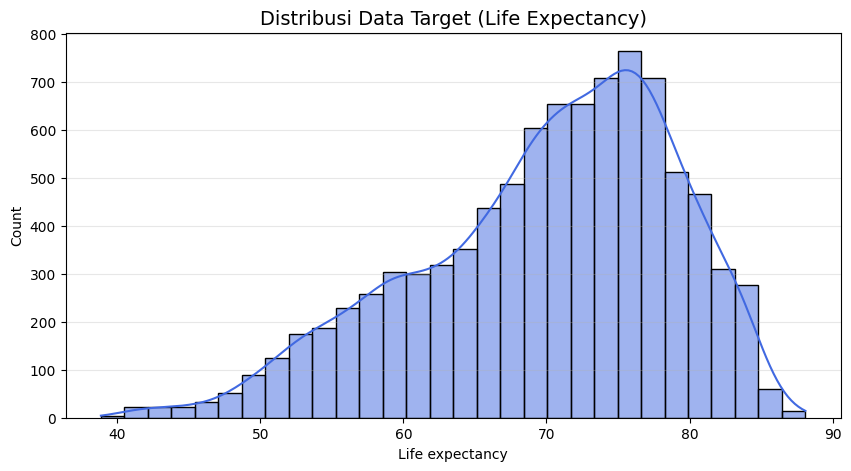

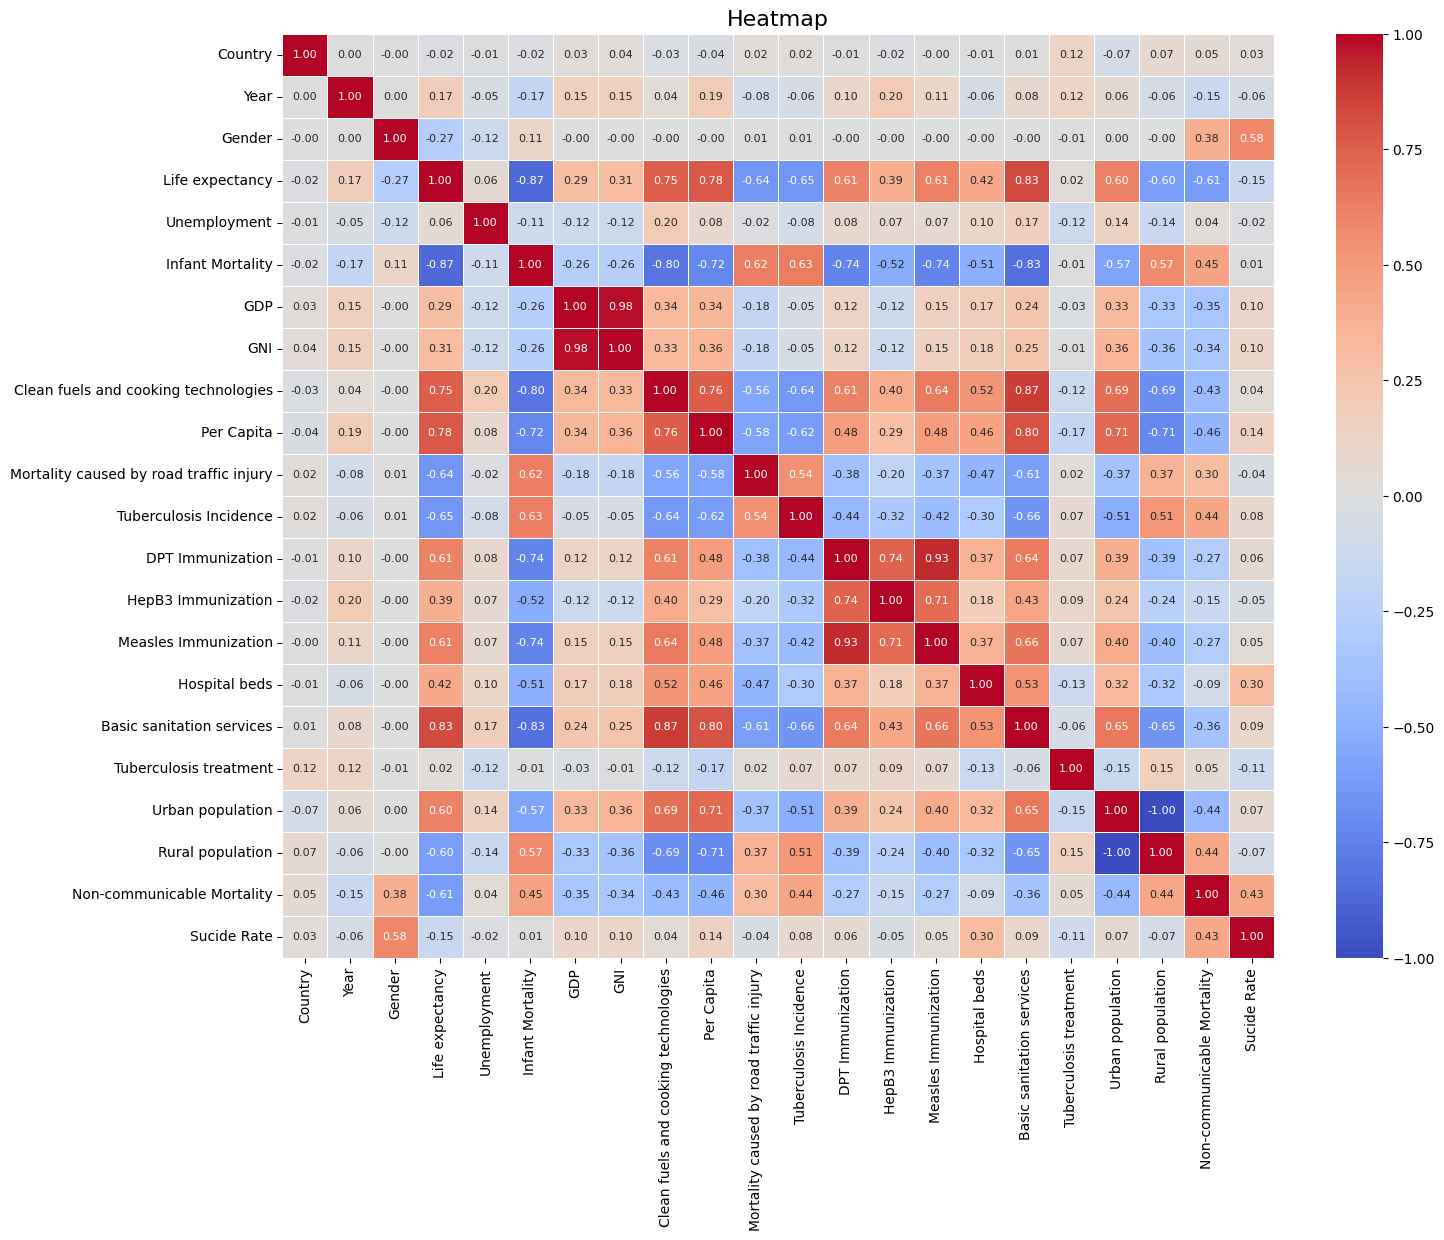


=== Urutan Korelasi Fitur Terhadap Target (Life Expectancy) ===
Life expectancy                            1.000000
Basic sanitation services                  0.826691
Per Capita                                 0.775700
Clean fuels and cooking technologies       0.751574
Measles Immunization                       0.611409
DPT Immunization                           0.608018
Urban population                           0.604460
Hospital beds                              0.417729
HepB3 Immunization                         0.390257
GNI                                        0.311606
GDP                                        0.294696
Year                                       0.174195
Unemployment                               0.058661
Tuberculosis treatment                     0.018995
Country                                   -0.016233
Sucide Rate                               -0.147888
Gender                                    -0.272156
Rural population                          -0.604460

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# --- TAHAP 3: EXPLORATORY DATA ANALYSIS (EDA) ---

# 1. Visualisasi Distribusi Target
plt.figure(figsize=(10, 5))
sns.histplot(df_clean['Life expectancy'], kde=True, color='royalblue', bins=30)
plt.title('Distribusi Data Target (Life Expectancy)', fontsize=14)
plt.grid(axis='y', alpha=0.3)
plt.show()

# 2. Matriks Korelasi Lengkap dengan Angka (Annotated Heatmap)
plt.figure(figsize=(16, 12))
# Menghitung korelasi Pearson
corr_matrix = df_clean.select_dtypes(include=[np.number]).corr()

# Membuat heatmap dengan angka (annot=True) dan format 2 angka di belakang koma (fmt='.2f')
sns.heatmap(corr_matrix,
            annot=True,
            fmt='.2f',
            cmap='coolwarm',
            linewidths=0.5,
            annot_kws={"size": 8})

plt.title('Heatmap', fontsize=16)
plt.show()

# 3. Korelasi Khusus Terhadap Target (Sorting)
print("\n=== Urutan Korelasi Fitur Terhadap Target (Life Expectancy) ===")
target_corr = corr_matrix['Life expectancy'].sort_values(ascending=False)
print(target_corr)

In [ ]:
import pandas as pd
import numpy as np

# --- ANALISIS FITUR TIDAK BERPENGARUH ---

# 1. Menghitung korelasi absolut terhadap target
# Kita gunakan nilai absolut agar korelasi negatif yang kuat (seperti Infant Mortality) tidak ikut terhapus
correlations = df_clean.corr()['Life expectancy'].abs().sort_values(ascending=False)

# 2. Menentukan Ambang Batas (Threshold)
# Secara profesional, fitur dengan korelasi < 0.1 dianggap sangat lemah pengaruhnya terhadap target
threshold = 0.1
weak_features = correlations[correlations < threshold].index.tolist()

print("="*50)
print("ANALISIS FITUR LEMAH")
print("="*50)
print(f"Ambang batas korelasi yang digunakan: {threshold}")
print(f"Fitur yang teridentifikasi tidak berpengaruh: {weak_features}")

# Tampilkan nilai korelasi fitur lemah tersebut
print("\nDetail Nilai Korelasi Fitur Lemah:")
print(correlations[weak_features])

# 3. Menghapus Kolom Secara Otomatis
# Kita simpan dataframe baru untuk menjaga integritas data asli
df_selected = df_clean.drop(columns=weak_features)

print("\n" + "="*50)
print("HASIL PENGHAPUSAN")
print("="*50)
print(f"Jumlah kolom sebelum: {df_clean.shape[1]}")
print(f"Jumlah kolom sesudah: {df_selected.shape[1]}")
print(f"Kolom yang tersisa: {df_selected.columns.tolist()}")

ANALISIS FITUR LEMAH
Ambang batas korelasi yang digunakan: 0.1
Fitur yang teridentifikasi tidak berpengaruh: ['Unemployment', 'Tuberculosis treatment', 'Country']

Detail Nilai Korelasi Fitur Lemah:
Unemployment              0.058661
Tuberculosis treatment    0.018995
Country                   0.016233
Name: Life expectancy, dtype: float64

HASIL PENGHAPUSAN
Jumlah kolom sebelum: 22
Jumlah kolom sesudah: 19
Kolom yang tersisa: ['Year', 'Gender', 'Life expectancy', 'Infant Mortality', 'GDP', 'GNI', 'Clean fuels and cooking technologies', 'Per Capita', 'Mortality caused by road traffic injury', 'Tuberculosis Incidence', 'DPT Immunization', 'HepB3 Immunization', 'Measles Immunization', 'Hospital beds', 'Basic sanitation services', 'Urban population', 'Rural population', 'Non-communicable Mortality', 'Sucide Rate']


In [ ]:
from sklearn.preprocessing import StandardScaler
import joblib

# 1. Tentukan X (Fitur) dan y (Target) dari df_selected
X = df_selected.drop(columns=['Life expectancy'])
y = df_selected['Life expectancy']

# 2. Re-Fit Scaler (HANYA pada kolom yang tersisa)
# Ini adalah tahap paling krusial agar file .pkl Anda sinkron
scaler_baru = StandardScaler()
X_scaled = scaler_baru.fit_transform(X)

### DATA SPLITTING

In [ ]:
from sklearn.model_selection import train_test_split

# --- TAHAP 4: DATA SPLITTING ---

# 1. Menyiapkan Fitur (X) dan Target (y) dari data yang sudah diseleksi
# Pastikan X menggunakan data yang sudah di-scaling dan difilter fiturnya
X = df_selected.drop(['Life expectancy'], axis=1)
y = df_selected['Life expectancy']

# 2. Definisi Variasi Rasio Pembagian Data (Training : Testing)
# Variasi 1: 70% Training, 30% Testing
# Variasi 2: 80% Training, 20% Testing
# Variasi 3: 90% Training, 10% Testing
ratios = [0.3, 0.2, 0.1]
split_names = ["70:30", "80:20", "90:10"]

# Dictionary untuk menyimpan data hasil splitting agar bisa digunakan di tahap model building
splits = {}

print("="*50)
print("TAHAPAN 4: DATA SPLITTING (3 VARIASI)")
print("="*50)

for i, test_size in enumerate(ratios):
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size, random_state=42)

    # Simpan ke dalam dictionary
    splits[split_names[i]] = {
        'X_train': X_train,
        'X_test': X_test,
        'y_train': y_train,
        'y_test': y_test
    }

    print(f"Variasi {i+1} ({split_names[i]}):")
    print(f"  - Jumlah Data Training : {X_train.shape[0]} sampel")
    print(f"  - Jumlah Data Testing  : {X_test.shape[0]} sampel")
    print(f"  - Total Fitur digunakan: {X_train.shape[1]}")
    print("-" * 30)

print("\nProses Data Splitting selesai. Data siap digunakan untuk pelatihan model.")

TAHAPAN 4: DATA SPLITTING (3 VARIASI)
Variasi 1 (70:30):
  - Jumlah Data Training : 6405 sampel
  - Jumlah Data Testing  : 2746 sampel
  - Total Fitur digunakan: 18
------------------------------
Variasi 2 (80:20):
  - Jumlah Data Training : 7320 sampel
  - Jumlah Data Testing  : 1831 sampel
  - Total Fitur digunakan: 18
------------------------------
Variasi 3 (90:10):
  - Jumlah Data Training : 8235 sampel
  - Jumlah Data Testing  : 916 sampel
  - Total Fitur digunakan: 18
------------------------------

Proses Data Splitting selesai. Data siap digunakan untuk pelatihan model.


### MODEL BUILDING

In [ ]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import pandas as pd
import numpy as np

# Inisialisasi model dasar
baseline_models = {
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "Random Forest": RandomForestRegressor(random_state=42),
    "XGBoost": XGBRegressor(random_state=42)
}

baseline_results = []

print("="*80)
print(f"{'Split':<10} | {'Algorithm':<15} | {'R2 (%)':<8} | {'MAE':<8} | {'RMSE':<8}")
print("-" * 80)

for split_name, data in splits.items():
    for name, model in baseline_models.items():
        # Training
        model.fit(data['X_train'], data['y_train'])
        preds = model.predict(data['X_test'])

        # Kalkulasi Metrik
        r2 = r2_score(data['y_test'], preds)
        mae = mean_absolute_error(data['y_test'], preds)
        mse = mean_squared_error(data['y_test'], preds)
        rmse = np.sqrt(mse)

        baseline_results.append({
            'Split': split_name,
            'Algorithm': name,
            'R2 Score (%)': round(r2 * 100, 2),
            'MAE': round(mae, 4),
            'MSE': round(mse, 4),
            'RMSE': round(rmse, 4)
        })
        print(f"{split_name:<10} | {name:<15} | {r2*100:>7.2f}% | {mae:>8.4f} | {rmse:>8.4f}")

df_baseline = pd.DataFrame(baseline_results)

Split      | Algorithm       | R2 (%)   | MAE      | RMSE    
--------------------------------------------------------------------------------
70:30      | Decision Tree   |   98.07% |   0.7000 |   1.2613
70:30      | Random Forest   |   99.28% |   0.5011 |   0.7703
70:30      | XGBoost         |   99.29% |   0.5266 |   0.7633
80:20      | Decision Tree   |   98.00% |   0.6997 |   1.2892
80:20      | Random Forest   |   99.40% |   0.4503 |   0.7061
80:20      | XGBoost         |   99.44% |   0.4917 |   0.6839
90:10      | Decision Tree   |   98.51% |   0.6181 |   1.1327
90:10      | Random Forest   |   99.52% |   0.4105 |   0.6425
90:10      | XGBoost         |   99.51% |   0.4691 |   0.6511


### HYPERPARAMETER TUNING

In [ ]:
from sklearn.model_selection import GridSearchCV

# Definisi parameter yang akan diuji
param_grids = {
    "Decision Tree": {
        'max_depth': [10, 20, None],
        'min_samples_split': [2, 5, 10]
    },
    "Random Forest": {
        'n_estimators': [100, 300],
        'max_depth': [15, 25, None],
        'min_samples_leaf': [1, 2]
    },
    "XGBoost": {
        'n_estimators': [300, 500],
        'learning_rate': [0.05, 0.1, 0.2],
        'max_depth': [6, 10]
    }
}

tuned_results = []
best_models_dict = {}

print("\n" + "="*80)
print("MENJALANKAN HYPERPARAMETER TUNING...")
print("-" * 80)

for split_name, data in splits.items():
    for name, model in baseline_models.items():
        # Proses Pencarian Parameter Terbaik
        grid_search = GridSearchCV(
            estimator=model,
            param_grid=param_grids[name],
            cv=3,
            scoring='r2',
            n_jobs=-1
        )
        grid_search.fit(data['X_train'], data['y_train'])

        # Menggunakan model terbaik untuk prediksi
        best_model = grid_search.best_estimator_
        preds = best_model.predict(data['X_test'])

        # Kalkulasi Metrik Setelah Tuning
        r2 = r2_score(data['y_test'], preds)
        mae = mean_absolute_error(data['y_test'], preds)
        mse = mean_squared_error(data['y_test'], preds)
        rmse = np.sqrt(mse)

        tuned_results.append({
            'Split Ratio': split_name,
            'Algorithm': name,
            'Best Params': grid_search.best_params_,
            'R2 Score (%)': round(r2 * 100, 2),
            'MAE': round(mae, 4),
            'MSE': round(mse, 4),
            'RMSE': round(rmse, 4)
        })

        # Simpan objek model untuk Tahap Comparison
        best_models_dict[f"{split_name}_{name}"] = best_model

        print(f"Optimized {name} ({split_name}) -> R2: {r2*100:.2f}% | MAE: {mae:.4f}")

df_tuned = pd.DataFrame(tuned_results)


MENJALANKAN HYPERPARAMETER TUNING...
--------------------------------------------------------------------------------
Optimized Decision Tree (70:30) -> R2: 98.07% | MAE: 0.7000
Optimized Random Forest (70:30) -> R2: 99.30% | MAE: 0.4917
Optimized XGBoost (70:30) -> R2: 99.55% | MAE: 0.4178
Optimized Decision Tree (80:20) -> R2: 98.15% | MAE: 0.6902
Optimized Random Forest (80:20) -> R2: 99.40% | MAE: 0.4457
Optimized XGBoost (80:20) -> R2: 99.66% | MAE: 0.3736
Optimized Decision Tree (90:10) -> R2: 98.71% | MAE: 0.6395
Optimized Random Forest (90:10) -> R2: 99.55% | MAE: 0.3963
Optimized XGBoost (90:10) -> R2: 99.72% | MAE: 0.3473


In [ ]:
# 1. Menyeleksi Model Terbaik berdasarkan R2 Score
best_run = df_tuned.sort_values(by='R2 Score (%)', ascending=False).iloc[0]

best_split = best_run['Split Ratio']
best_algo_name = best_run['Algorithm']
best_model_obj = best_models_dict[f"{best_split}_{best_algo_name}"]

print("="*60)
print("HASIL SELEKSI MODEL TERBAIK")
print("="*60)
print(f"Algoritma Terbaik : {best_algo_name}")
print(f"Split Ratio Ideal : {best_split}")
print(f"Parameter Terbaik : {best_run['Best Params']}")
print(f"R2 Score Final    : {best_run['R2 Score (%)']}%")
print("-" * 60)

HASIL SELEKSI MODEL TERBAIK
Algoritma Terbaik : XGBoost
Split Ratio Ideal : 90:10
Parameter Terbaik : {'learning_rate': 0.1, 'max_depth': 6, 'n_estimators': 500}
R2 Score Final    : 99.72%
------------------------------------------------------------


### MODEL EVALUATION


=== EVALUASI MENDALAM MODEL TERBAIK ===
R-Squared (R2)         : 0.9972
Mean Absolute Error    : 0.3473 tahun
Mean Squared Error     : 0.2364
Root Mean Squared Error: 0.4862 tahun


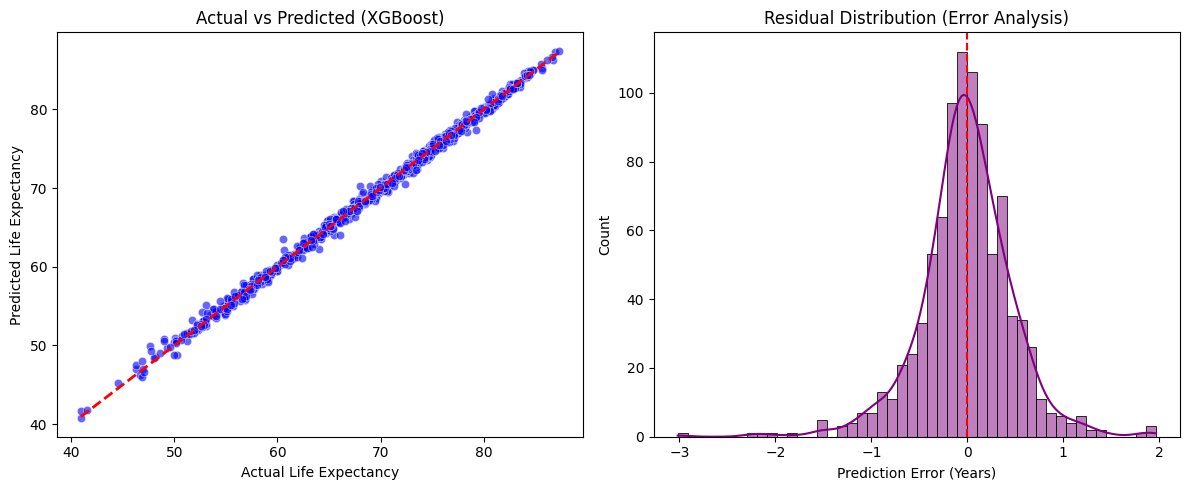

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Ambil data testing yang sesuai dengan split terbaik
data_eval = splits[best_split]
y_actual = data_eval['y_test']
y_pred = best_model_obj.predict(data_eval['X_test'])

# Kalkulasi Metrik Evaluasi Lengkap
mae = mean_absolute_error(y_actual, y_pred)
mse = mean_squared_error(y_actual, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_actual, y_pred)

print("\n=== EVALUASI MENDALAM MODEL TERBAIK ===")
print(f"R-Squared (R2)         : {r2:.4f}")
print(f"Mean Absolute Error    : {mae:.4f} tahun")
print(f"Mean Squared Error     : {mse:.4f}")
print(f"Root Mean Squared Error: {rmse:.4f} tahun")

# Visualisasi 1: Actual vs Predicted
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.scatterplot(x=y_actual, y=y_pred, alpha=0.6, color='blue')
plt.plot([y_actual.min(), y_actual.max()], [y_actual.min(), y_actual.max()], 'r--', lw=2)
plt.title(f'Actual vs Predicted ({best_algo_name})')
plt.xlabel('Actual Life Expectancy')
plt.ylabel('Predicted Life Expectancy')

# Visualisasi 2: Residual Plot
# Digunakan untuk melihat apakah error terdistribusi secara acak
residuals = y_actual - y_pred
plt.subplot(1, 2, 2)
sns.histplot(residuals, kde=True, color='purple')
plt.axvline(0, color='red', linestyle='--')
plt.title('Residual Distribution (Error Analysis)')
plt.xlabel('Prediction Error (Years)')

plt.tight_layout()
plt.show()

### MODEL COMPARISON

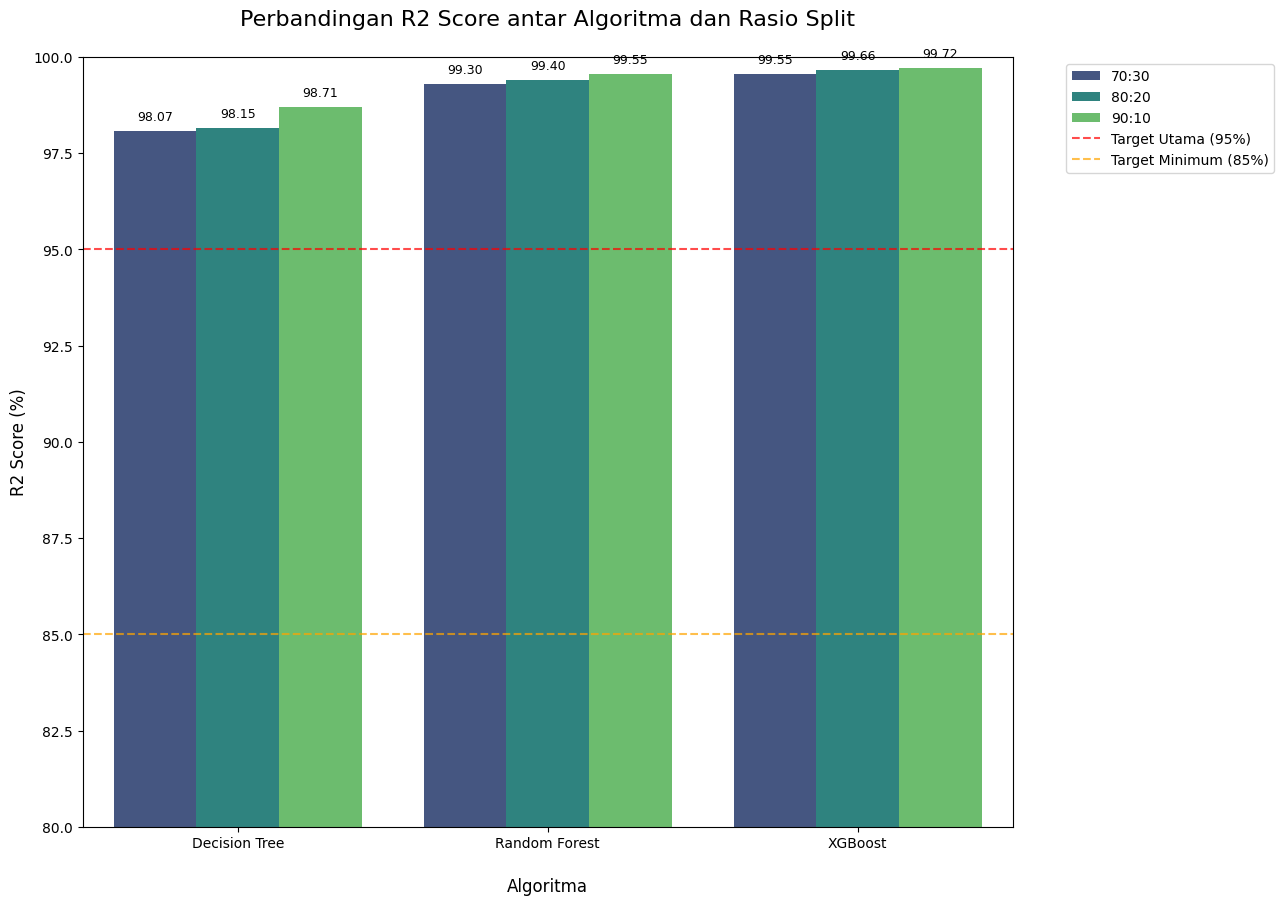





                          ANALISIS ERROR (MAE & RMSE)                           




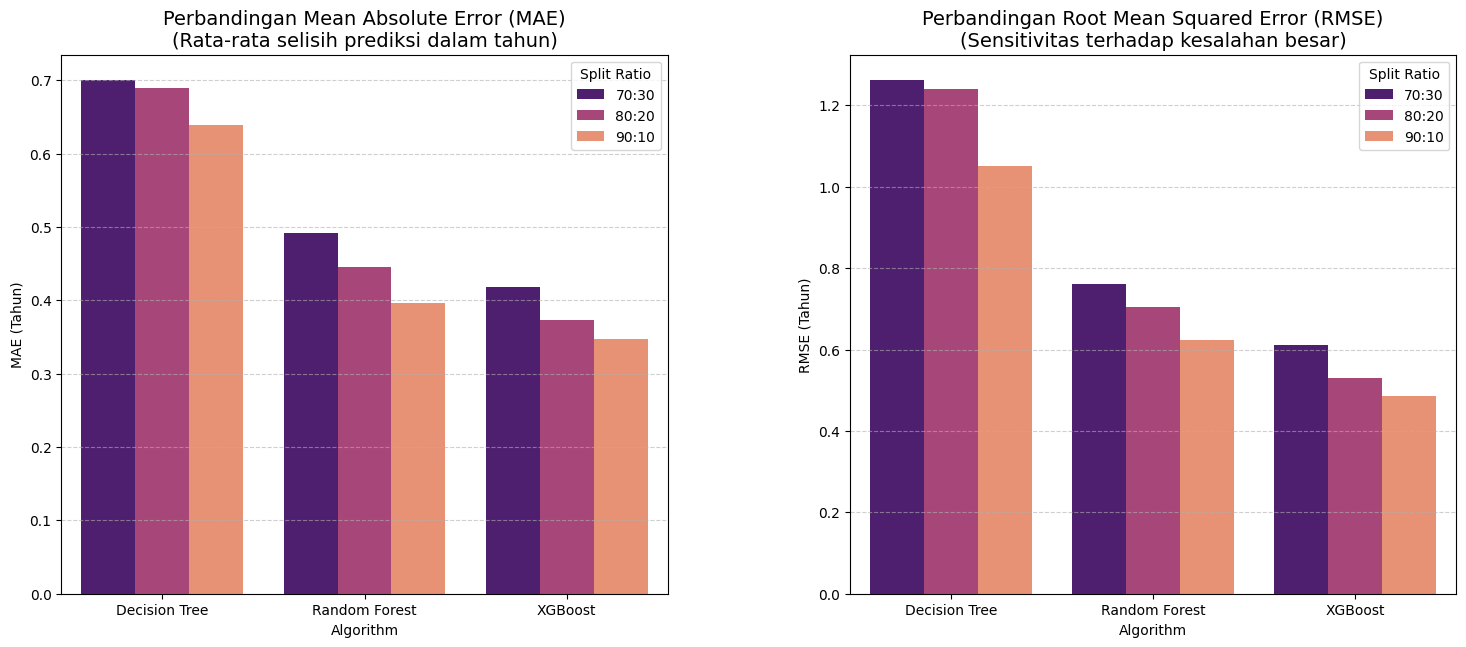

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# --- TAHAP 8: MODEL COMPARISON (DENGAN TATA LETAK RAPI) ---

# 1. Menyiapkan Data
df_comparison = df_tuned.copy()

# ==========================================================
# VISUALISASI 1: AKURASI (R2 SCORE)
# ==========================================================
plt.figure(figsize=(12, 10))
ax = sns.barplot(x='Algorithm', y='R2 Score (%)', hue='Split Ratio', data=df_comparison, palette='viridis')

# Menambahkan garis target untuk referensi
plt.axhline(95, color='red', linestyle='--', alpha=0.7, label='Target Utama (95%)')
plt.axhline(85, color='orange', linestyle='--', alpha=0.7, label='Target Minimum (85%)')

plt.title('Perbandingan R2 Score antar Algoritma dan Rasio Split\n', fontsize=16)
plt.ylabel('R2 Score (%)', fontsize=12)
plt.xlabel('\nAlgoritma', fontsize=12)
plt.ylim(80, 100)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

# Menampilkan angka di atas setiap bar
for p in ax.patches:
    ax.annotate(format(p.get_height(), '.2f'),
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha = 'center', va = 'center',
                xytext = (0, 10),
                textcoords = 'offset points',
                fontsize=9)

plt.show() # Menampilkan plot pertama

# MEMBERIKAN JARAK VISUAL DI OUTPUT
print("\n" * 3)
print("="*80)
print("ANALISIS ERROR (MAE & RMSE)".center(80))
print("="*80)
print("\n")

# ==========================================================
# VISUALISASI 2 & 3: ANALISIS KESALAHAN (ERROR)
# ==========================================================
# Kita gunakan subplots tapi dengan spasi antar kolom yang lebar (wspace)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))
plt.subplots_adjust(wspace=0.3) # Memberikan jarak horizontal antar dua grafik

# Plot MAE (Semakin rendah semakin baik)
sns.barplot(x='Algorithm', y='MAE', hue='Split Ratio', data=df_comparison, ax=ax1, palette='magma')
ax1.set_title('Perbandingan Mean Absolute Error (MAE)\n(Rata-rata selisih prediksi dalam tahun)', fontsize=14)
ax1.set_ylabel('MAE (Tahun)')
ax1.grid(axis='y', linestyle='--', alpha=0.6)

# Plot RMSE (Semakin rendah semakin baik)
sns.barplot(x='Algorithm', y='RMSE', hue='Split Ratio', data=df_comparison, ax=ax2, palette='magma')
ax2.set_title('Perbandingan Root Mean Squared Error (RMSE)\n(Sensitivitas terhadap kesalahan besar)', fontsize=14)
ax2.set_ylabel('RMSE (Tahun)')
ax2.grid(axis='y', linestyle='--', alpha=0.6)

plt.show() # Menampilkan plot kedua dan ketiga

In [ ]:
import joblib
joblib.dump(scaler_baru, 'scalerr.pkl') # Hasilnya akan 18 kolom
joblib.dump(X.columns.tolist(), 'feature_columnss.pkl')
joblib.dump(best_model_obj, 'best_modell.pkl')

['best_modell.pkl']

### INFERENCE

In [ ]:
import pandas as pd
import numpy as np
import joblib

# 1. Load file yang sudah disinkronkan (Hasil re-fit 18 fitur)
model = joblib.load('best_modell.pkl')
scaler = joblib.load('scalerr.pkl')
features = joblib.load('feature_columnss.pkl')

# 2. Buat Data Baru (Contoh data mentah)
# Pastikan nama key sesuai dengan nama kolom di dataset asli
data_baru = {
    'Year': 2024,
    'Gender': 0,
    'Infant Mortality': 12.5,
    'GDP': 4500.0,
    'GNI': 4200.0,
    'Clean fuels and cooking technologies': 85.0,
    'Per Capita': 3500.0,
    'Mortality caused by road traffic injury': 10.2,
    'Tuberculosis Incidence': 120.0,
    'DPT Immunization': 95.0,
    'HepB3 Immunization': 90.0,
    'Measles Immunization': 92.0,
    'Hospital beds': 2.5,
    'Basic sanitation services': 88.0,
    'Urban population': 55.0,
    'Rural population': 45.0,
    'Non-communicable Mortality': 15.0,
    'Sucide Rate': 8.5
}

# 3. Proses Inference
def predict_life_expectancy(data_dict):
    # Convert ke DataFrame
    df = pd.DataFrame([data_dict])

    # Pastikan urutan kolom sesuai (Menghindari error mismatch)
    df = df[features]

    # Transformasi Log (Hanya jika kolom tersebut ada)
    log_cols = ['GDP', 'GNI', 'Per Capita', 'Sucide Rate']
    for col in log_cols:
        if col in df.columns:
            df[col] = np.log1p(df[col])

    # Scaling
    df_scaled = scaler.transform(df)

    # Prediksi
    hasil = model.predict(df_scaled)
    return hasil[0]

# Jalankan
print(f"Hasil Prediksi: {predict_life_expectancy(data_baru):.2f} Tahun")

Hasil Prediksi: 78.43 Tahun
